In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [6]:
DATA_FILE = r"C:\Users\rouna\Documents\BITS Pilani WILP\Semester 4\Dissertation\AIMLCZG628T\datasets\Skoltech_Anomaly_Benchmark\preprocessed_skab_dataset.csv"

dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
datetime,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.6640,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.3380,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.6640,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000,0.0,No Anomaly


## Univariate Analysis

In [84]:
def plot_numerical_distribution_plot(df, title=None, stat="count"):
    fig, axs = plt.subplots(4, 2, figsize=(20, 20))
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.histplot(data=df, x="Accelerometer1RMS", kde=True, ax=axs[0, 0], hue="description", stat=stat)
    axs[0, 0].set_title("Distribution of Accelerometer1RMS")

    sns.histplot(data=df, x="Accelerometer2RMS", kde=True, ax=axs[0, 1], hue="description", stat=stat)
    axs[0, 1].set_title("Distribution of Accelerometer2RMS")

    sns.histplot(data=df, x="Current", kde=True, ax=axs[1, 0], hue="description", stat=stat)
    axs[1, 0].set_title("Distribution of Current")

    sns.histplot(data=df, x="Voltage", kde=True, ax=axs[1, 1], hue="description", stat=stat)
    axs[1, 1].set_title("Distribution of Voltage")

    sns.histplot(data=df, x="Pressure", kde=True, ax=axs[2, 0], hue="description", stat=stat)
    axs[2, 0].set_title("Distribution of Pressure")

    sns.histplot(data=df, x="Volume Flow RateRMS", kde=True, ax=axs[2, 1], hue="description", stat=stat)
    axs[2, 1].set_title("Distribution of Volume Flow RateRMS")

    sns.histplot(data=df, x="Temperature", kde=True, ax=axs[3, 0], hue="description", stat=stat)
    axs[3, 0].set_title("Distribution of Temperature")

    sns.histplot(data=df, x="Thermocouple", kde=True, ax=axs[3, 1], hue="description", stat=stat)
    axs[3, 1].set_title("Distribution of Thermocouple")

    plt.tight_layout()
    plt.show()

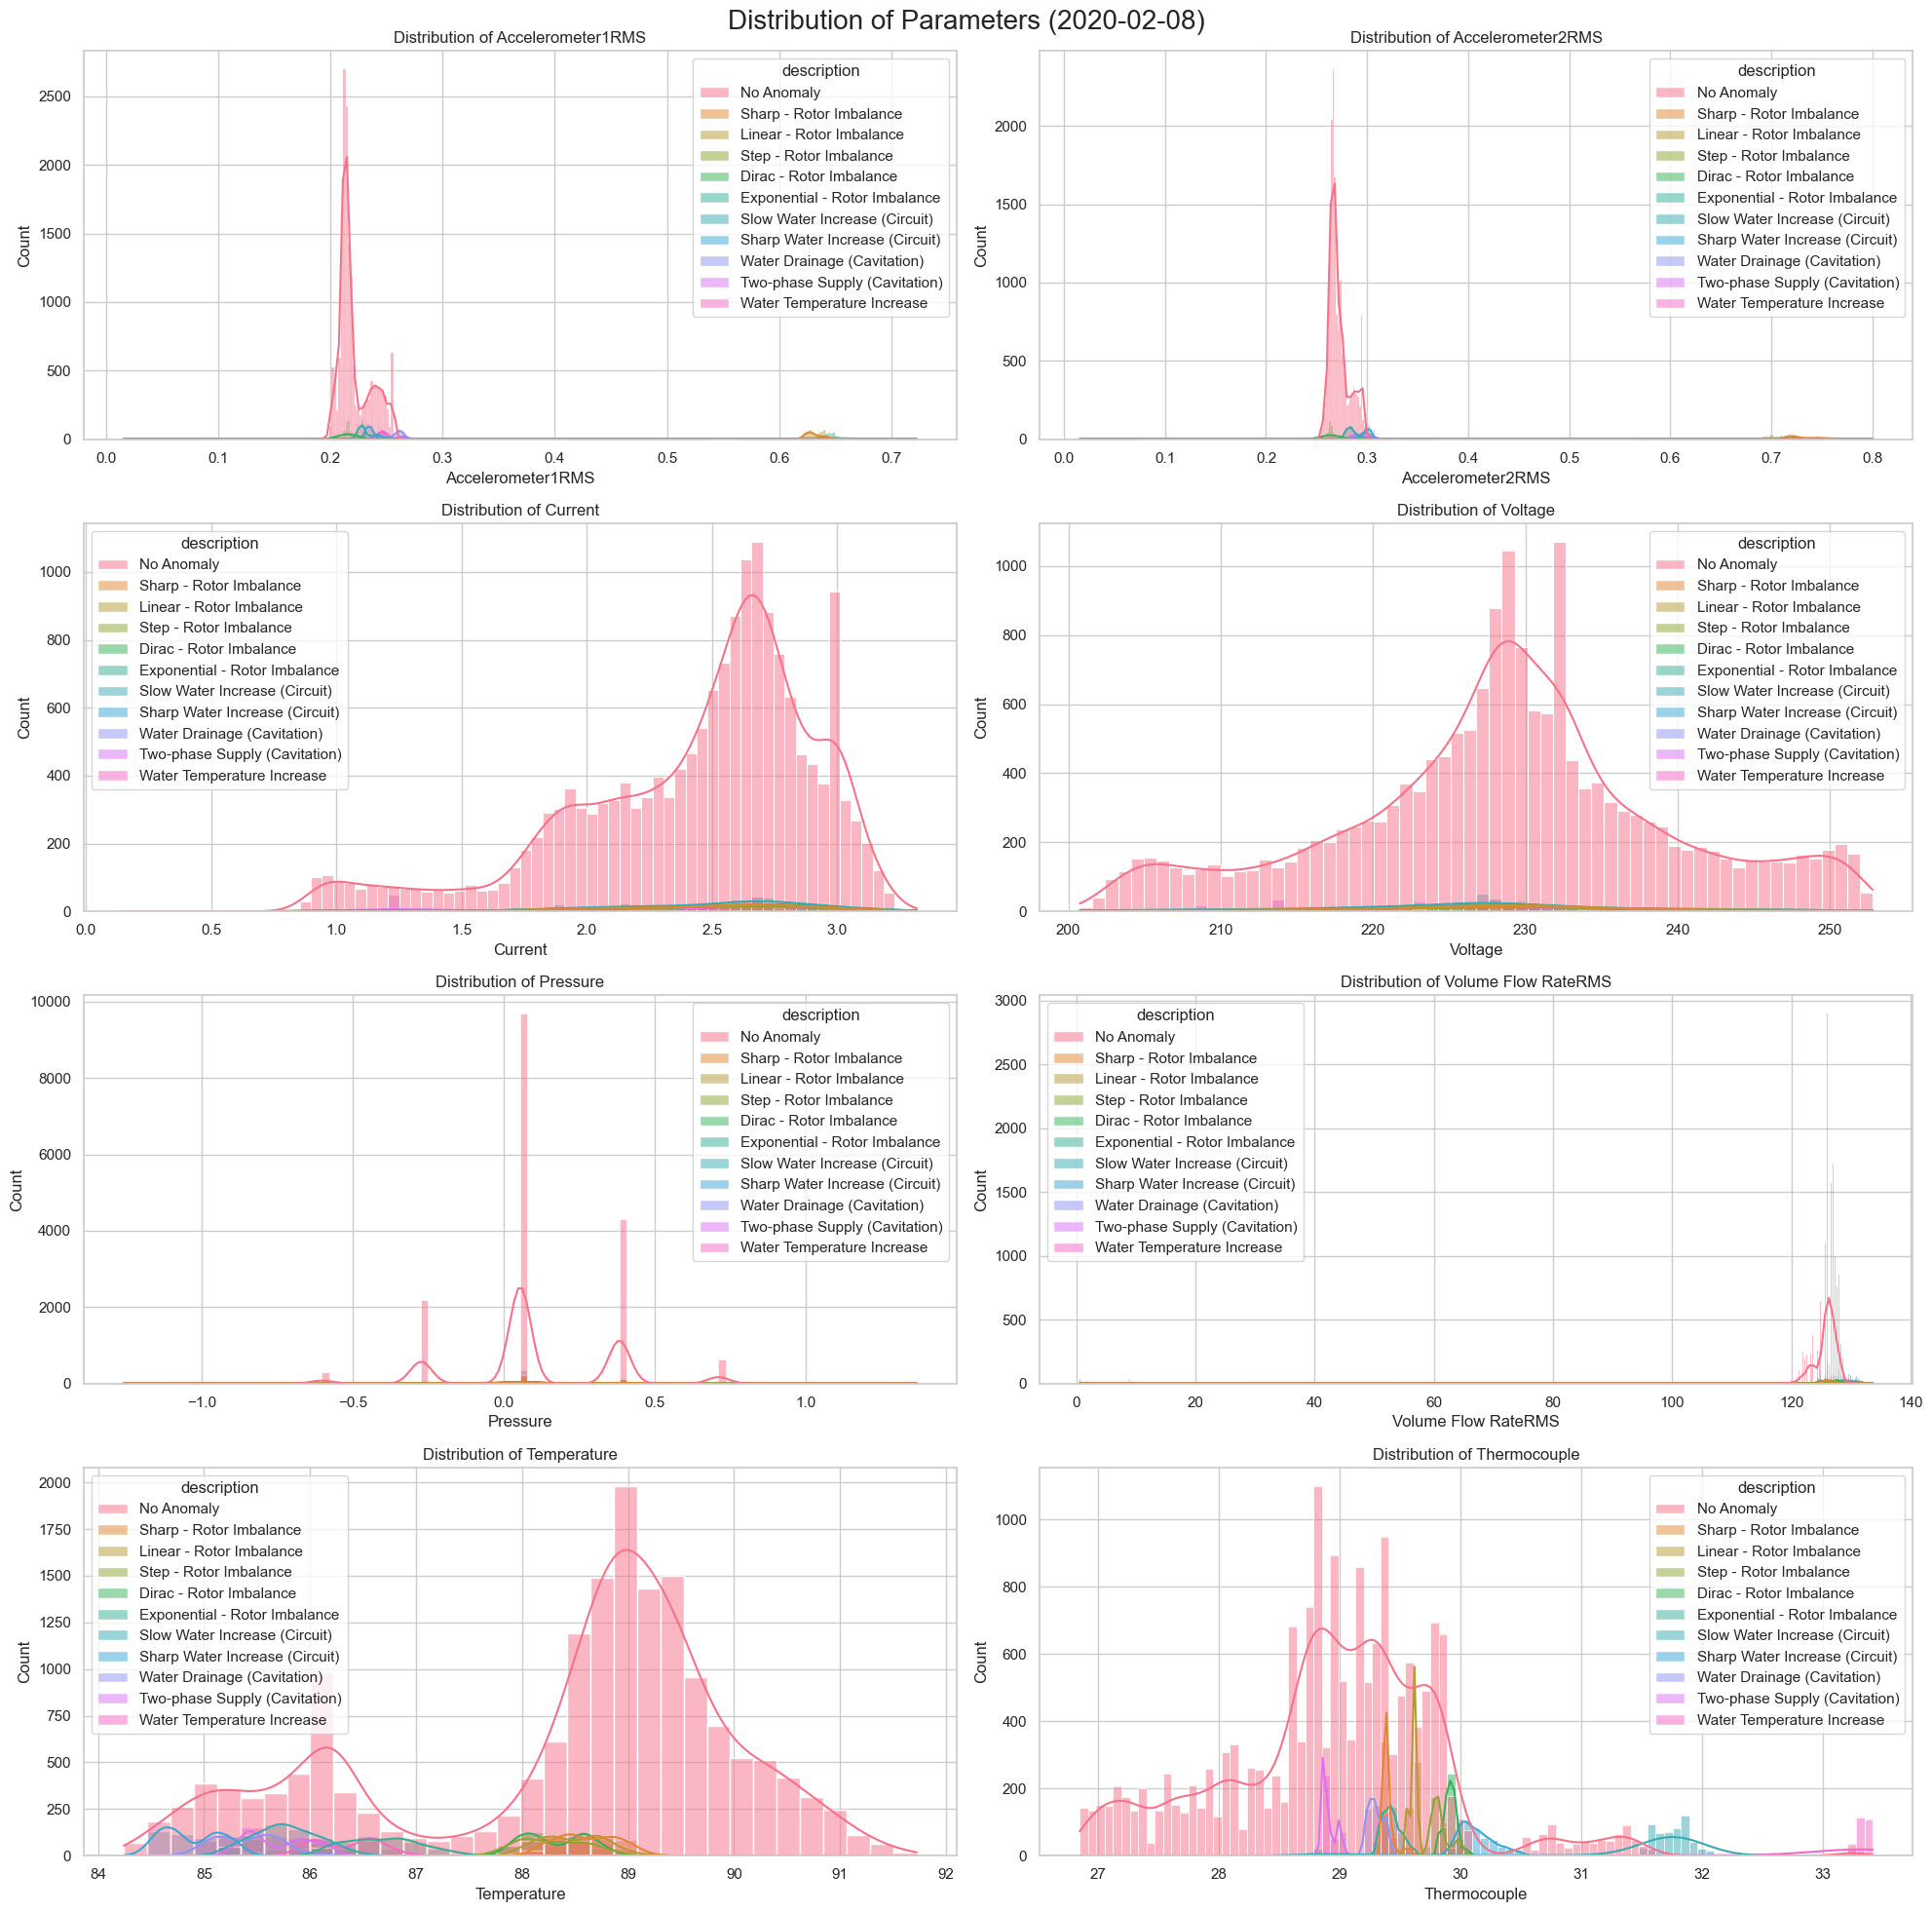

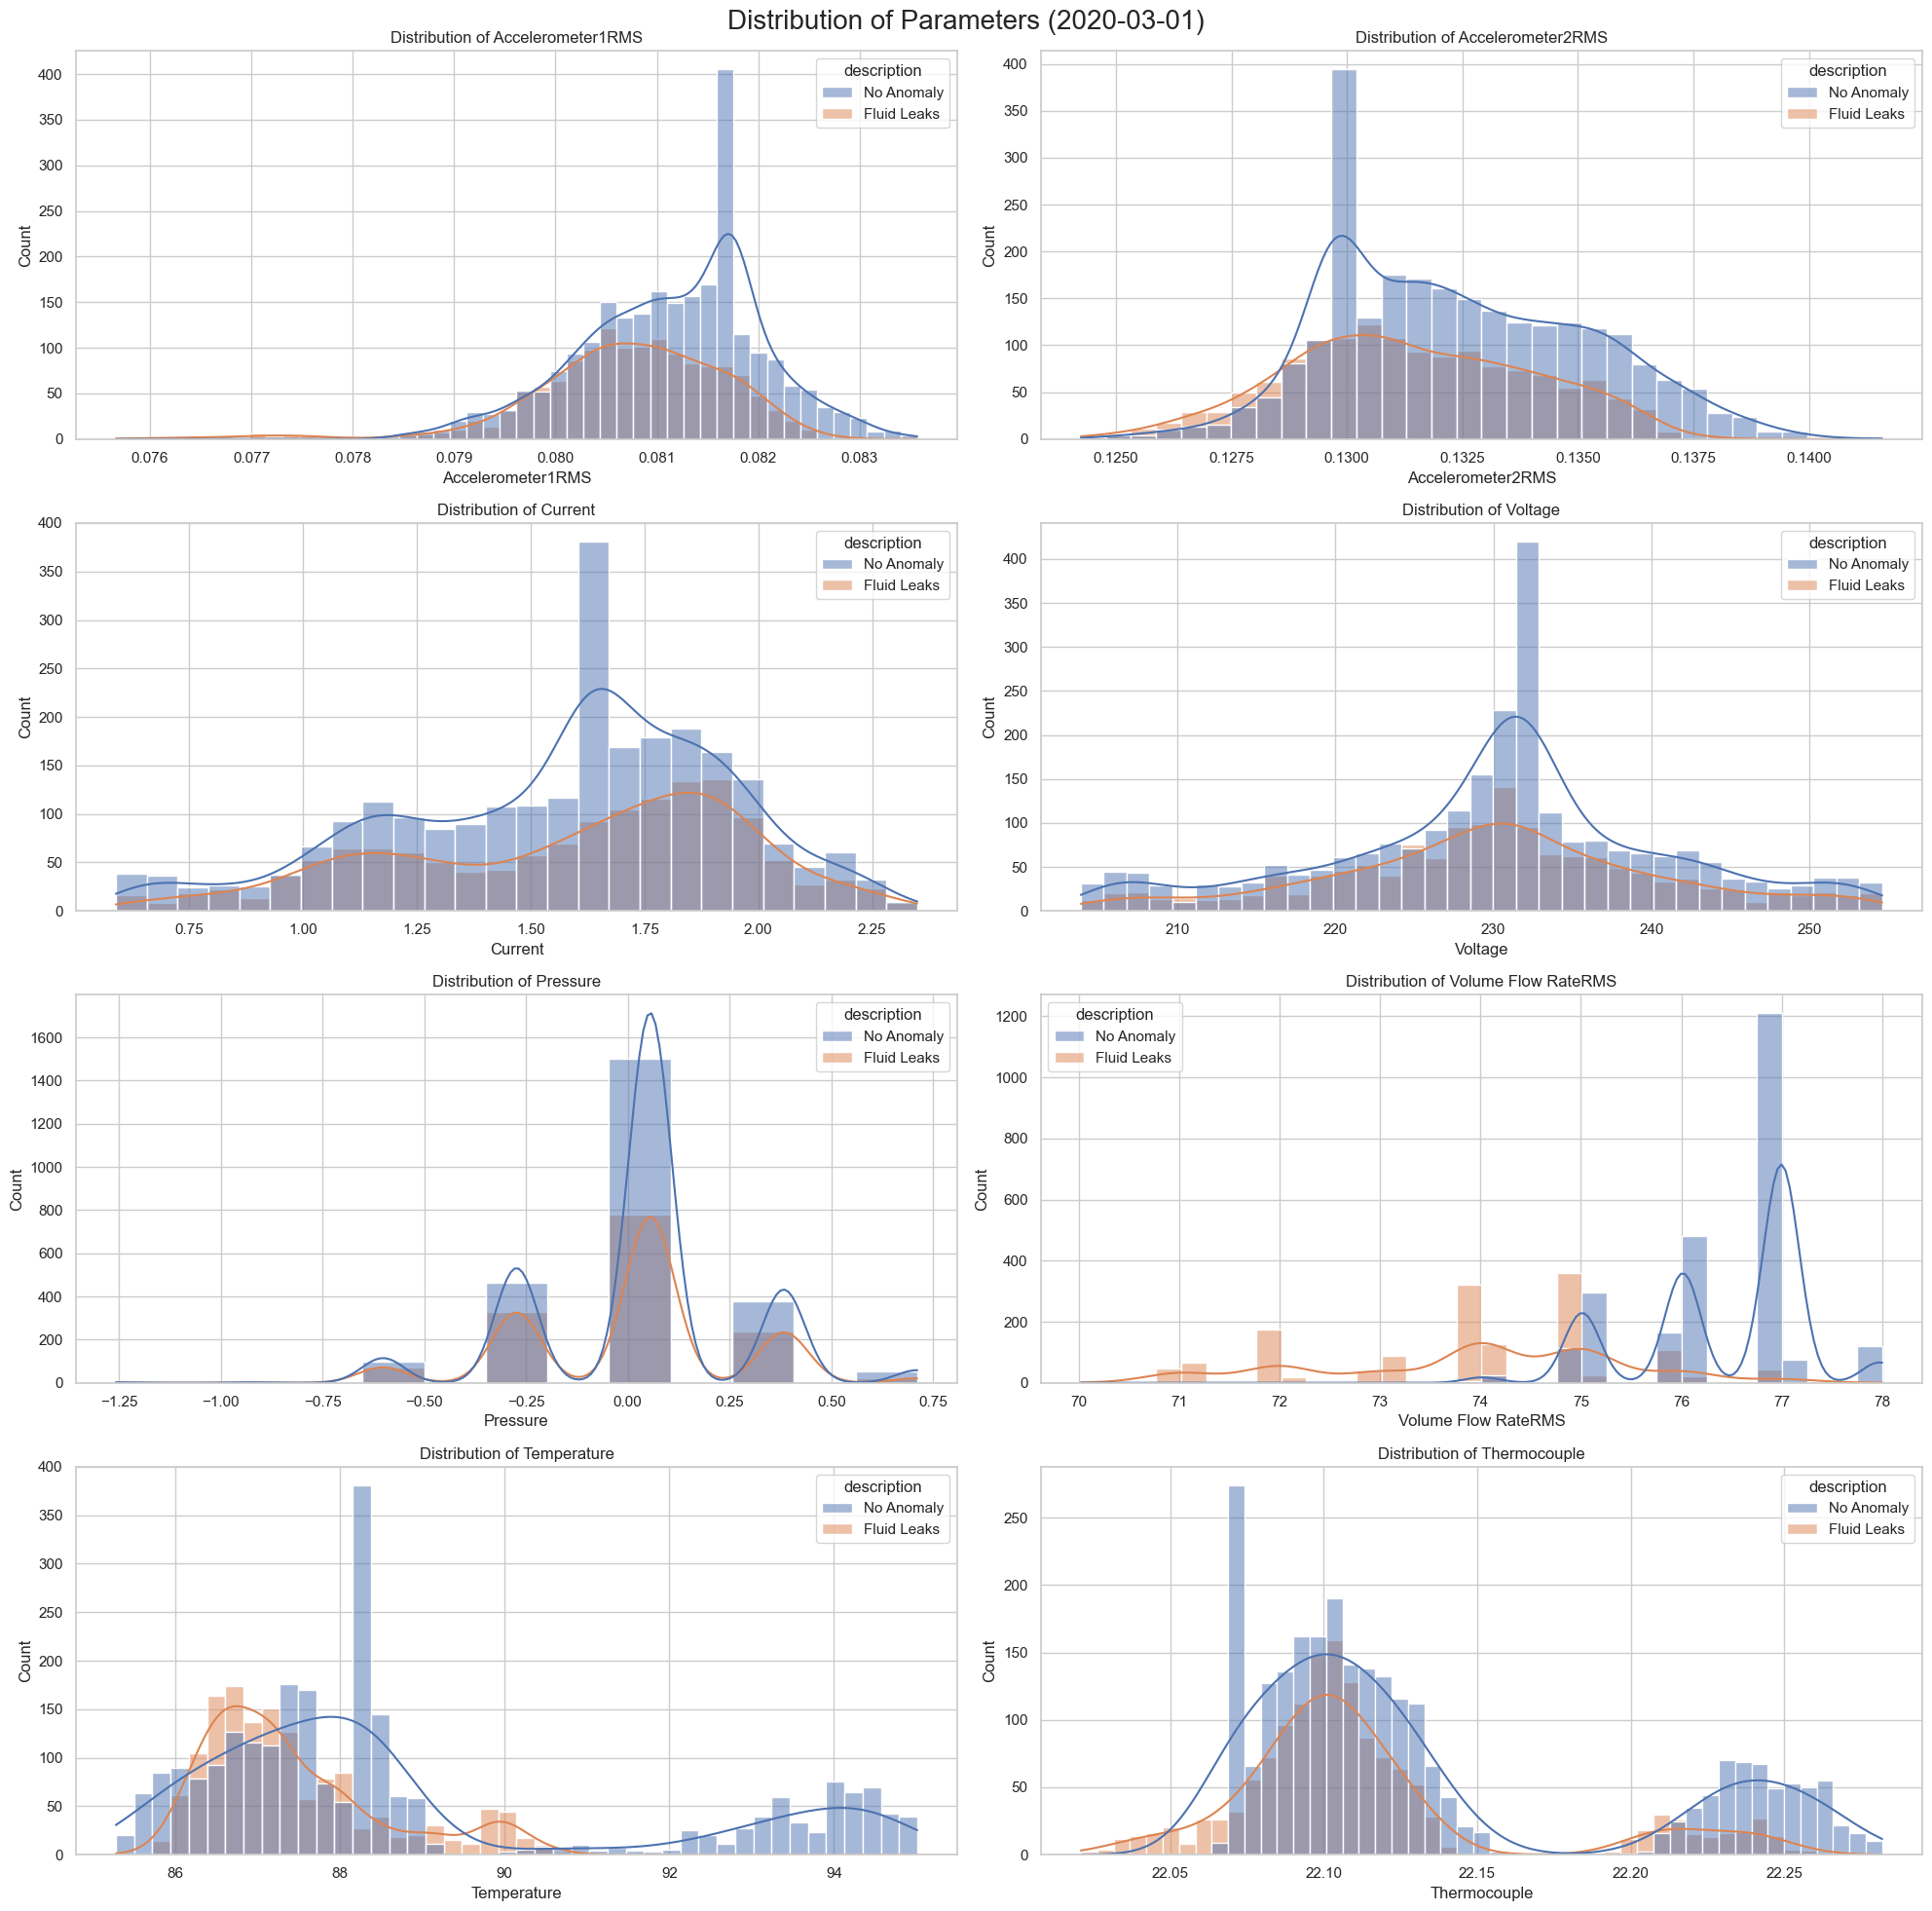

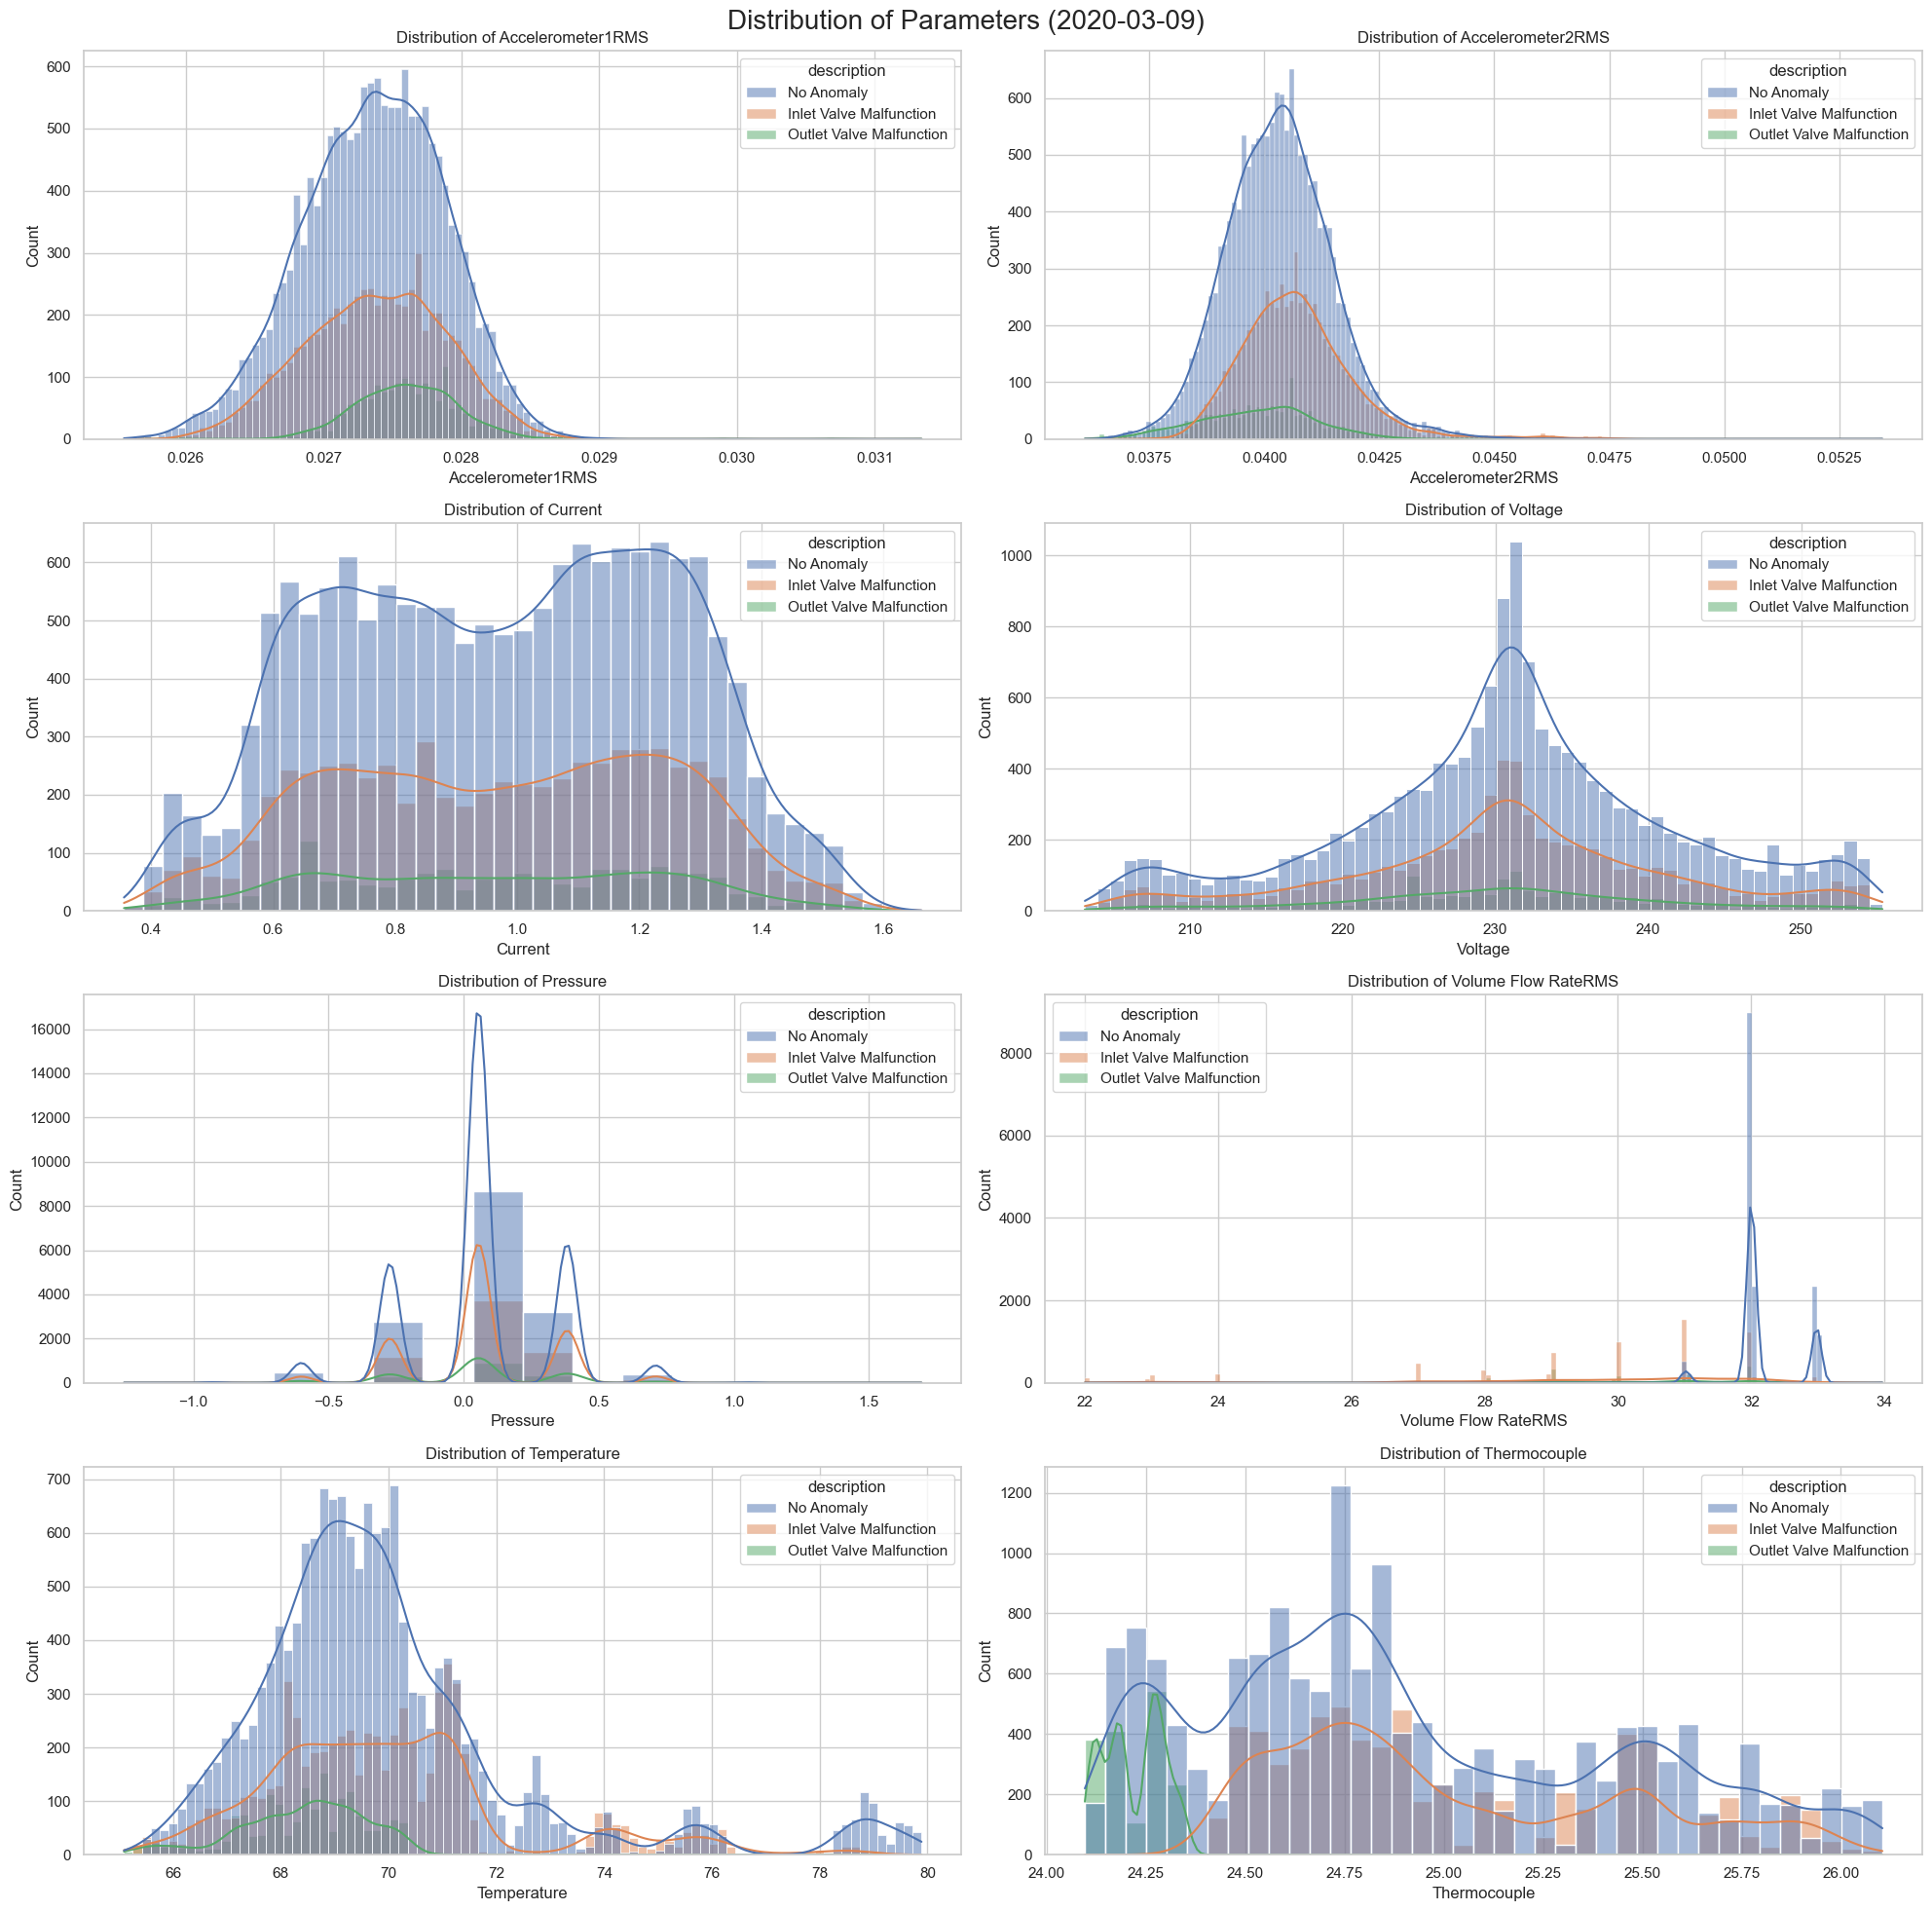

In [86]:
plot_numerical_distribution_plot(dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], title="Distribution of Parameters (2020-02-08)")
plot_numerical_distribution_plot(dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], title="Distribution of Parameters (2020-03-01)")
plot_numerical_distribution_plot(dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], title="Distribution of Parameters (2020-03-09)")

In [99]:
def plot_categorical_distribution_plot(dataframe, column_name, title=None):
    """
    Plots the distribution of a categorical column with counts on top of bars.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
        title (str, optional): The title of the plot. Defaults to None.
    """
    plt.figure(figsize=(15, 6)) # Adjusted figure size for better readability
    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    # Create the countplot
    ax = sns.countplot(y=column_name, data=dataframe, order=dataframe[column_name].value_counts().index, palette='viridis', stat="percent")

    # Add count labels on top of each bar
    for p in ax.patches:
        width = p.get_width()    # Get the width of the bar (which is the count)
        plt.text(width + 0.5,     # Set the x position of the text slightly to the right of the bar
                 p.get_y() + p.get_height() / 2, # Set the y position at the middle of the bar
                 '{:0.2f}%'.format(width), # Format the count to an integer
                 ha='left', va='center', fontsize=10, color='black') # Text alignment and style

    plt.xlabel('Count', fontsize=12) # Label for x-axis
    plt.ylabel(column_name.replace('_', ' ').title(), fontsize=12) # Formatted label for y-axis
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

C:\Users\rouna\AppData\Local\Temp\ipykernel_12716\4003324623.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=column_name, data=dataframe, order=dataframe[column_name].value_counts().index, palette='viridis', stat="percent")


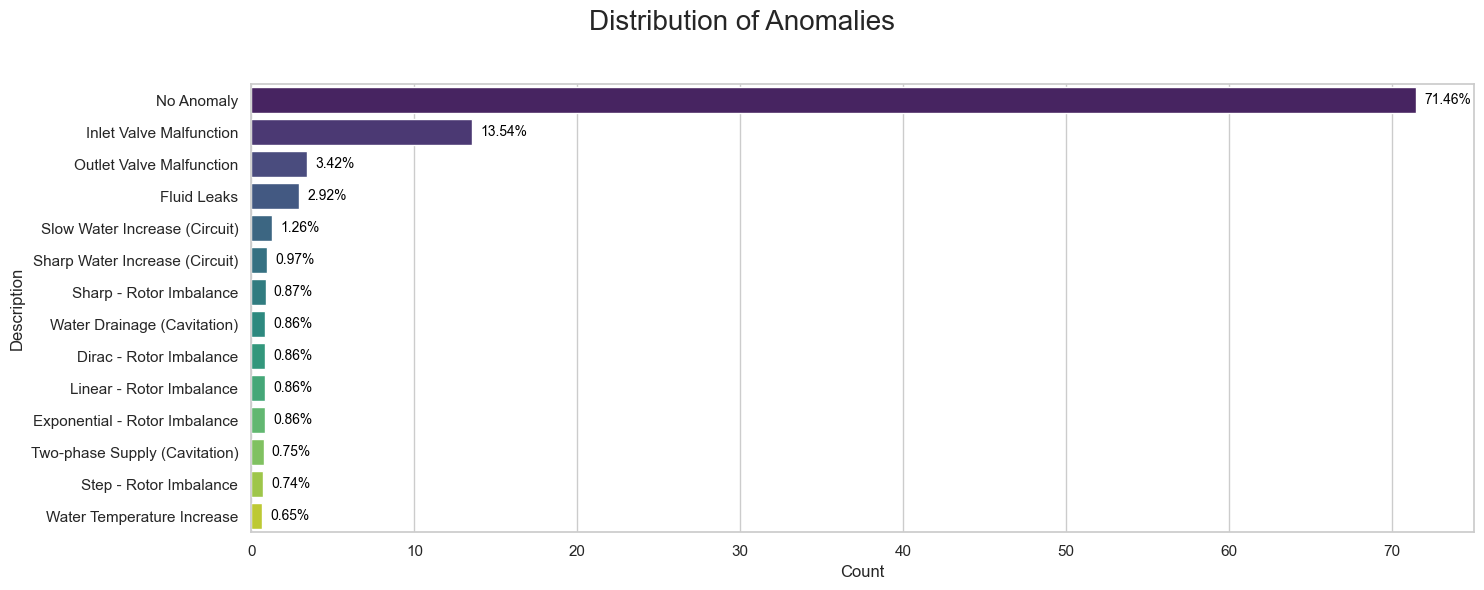

In [100]:
plot_categorical_distribution_plot(dataframe, column_name="description", title="Distribution of Anomalies")

## Bivariate Analysis